In [6]:
import torch
import torch.nn as nn
import pandas as pd
from GAD_util import *

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"running on {device}")

running on mps


In [8]:
sequence_length = 30
dt = 1/250
learning_rate = 0.005
batch_size = 10000
batch_num= 20
epoch_num = 300
T = dt * sequence_length

In [9]:
loss_fn = loss_exp_OCE(1.3,X_max=True, p0_mode='calculate')

In [13]:
name = 'GAD_AAPL_fix_N1e4_delta0.1_alpha_1_1_part1.pt'

In [16]:
# Load the network
network = RNN_BN_simple(1, sequence_length, device=device).to(device=device)
network.eval()
network.load_state_dict(torch.load(f'../Result/{name}'))

/var/folders/w7/ct4fpj8x3jg4d93ghy6mf65r0000gn/T/ipykernel_79243/4067876768.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  network.load_state_dict(torch.load(f'../Resul

<All keys matched successfully>

In [17]:
# Evaluation on the tested price trajectory
def PnL(price_single):
    # Calculate the PnL for a single price trajectory
    holding = network(price_single[:-1].unsqueeze(-1).unsqueeze(0)).squeeze()
    delta_price = price_single[1:] - price_single[:-1]
    Pnl = (holding * delta_price.squeeze()).sum().item()
    payoff = max((price_single.mean()-10).item(),0)
    return (Pnl-payoff)
data = pd.read_csv("../Data/stocks_close_prices_2008_2021.csv")
company = 'MSFT'
test_period= data[company].values[2880:2911]
test_period = test_period / test_period[0] * 10
price_single_test = torch.tensor(test_period, dtype=torch.float32, device=device)

result = PnL(price_single_test)
print(result)

8.79250431060791


In [21]:
# Evaluation on the dataset
def performance_dataset(price):
    # Compute the loss for the given price data
    holding = network(price[:,:-1].unsqueeze(-1)).squeeze()
    loss = loss_fn(holding, price)
    return loss.item()
# load data
company = 'MSFT'
run_name = f'GAD_{company}'
# price = torch.load(f"../Data/{run_name}/GAD_fix_val.pt").to(device)
# price = torch.load(f"../Data/{run_name}/GAD_fix_test.pt").to(device)
# price = torch.load(f"../Data/{run_name}/GAD_fix_train.pt").to(device)
# price = torch.load(f"../Data/{run_name}/GAD_robust_val.pt").to(device)
price = torch.load(f"../Data/{run_name}/GAD_robust_test.pt").to(device)
# price = torch.load(f"../Data/{run_name}/GAD_robust_train.pt").to(device)
# price = torch.load(f"../Data/{run_name}/GAD_real_test.pt").to(device)

# Evaluate the performance of the network
result = performance_dataset(price)
print(result)

/var/folders/w7/ct4fpj8x3jg4d93ghy6mf65r0000gn/T/ipykernel_79243/639987902.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  price = torch.load(f"../Data/{run_name}/GAD_r

0.47677552700042725


/var/folders/w7/ct4fpj8x3jg4d93ghy6mf65r0000gn/T/ipykernel_79243/3936133328.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  price_real = torch.load(f"../Data/{run_name}/

First 10 individual PnLs: [8.00256061553955, 21.52552032470703, 12.093910217285156, 1.7102394104003906, 15.466482162475586, 0.20562458038330078, -0.34716707468032837, -0.5285141468048096, 5.552085876464844, 10.713114738464355]


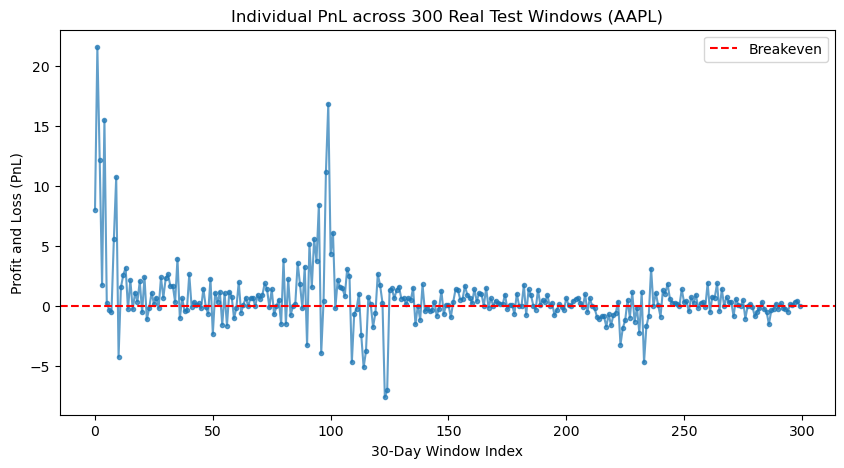

In [22]:
import matplotlib.pyplot as plt

# Make sure you have loaded the real test data
company = 'AAPL' # Change to your target company
run_name = f'GAD_{company}'
price_real = torch.load(f"../Data/{run_name}/GAD_real_test.pt").to(device)

individual_pnls = []

# Loop through all 300 sequences
for i in range(price_real.shape[0]):
    # Extract the single 31-day trajectory
    single_trajectory = price_real[i]
    
    # Calculate PnL for this specific trajectory
    pnl = PnL(single_trajectory)
    individual_pnls.append(pnl)

# Print the first 10 results
print("First 10 individual PnLs:", individual_pnls[:10])

# Optional: Plot the PnL distribution to see how your strategy performed across all 300 timeframes
plt.figure(figsize=(10, 5))
plt.plot(individual_pnls, marker='o', linestyle='-', markersize=3, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', label='Breakeven')
plt.title(f'Individual PnL across 300 Real Test Windows ({company})')
plt.xlabel('30-Day Window Index')
plt.ylabel('Profit and Loss (PnL)')
plt.legend()
plt.show()
